In [14]:
# ============================================
# GLOBAL VISUALIZATION SETTINGS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [1]:
# ============================================
# LOAD FEATURE ENGINEERED DATASET
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"data/processed/flights_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(3000000, 38)


In [3]:
# ============================================
# RESTORE CATEGORICAL TYPES
# ============================================

categorical_cols = [
"AIRLINE",
"AIRLINE_DOT",
"AIRLINE_CODE",
"ORIGIN",
"ORIGIN_CITY",
"DEST",
"DEST_CITY",
"CANCELLATION_CODE",
"ROUTE",
"DAY_OF_WEEK"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print("Categorical types restored")

Categorical types restored


In [4]:
# ============================================
# CONVERT DATE COLUMN
# ============================================

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

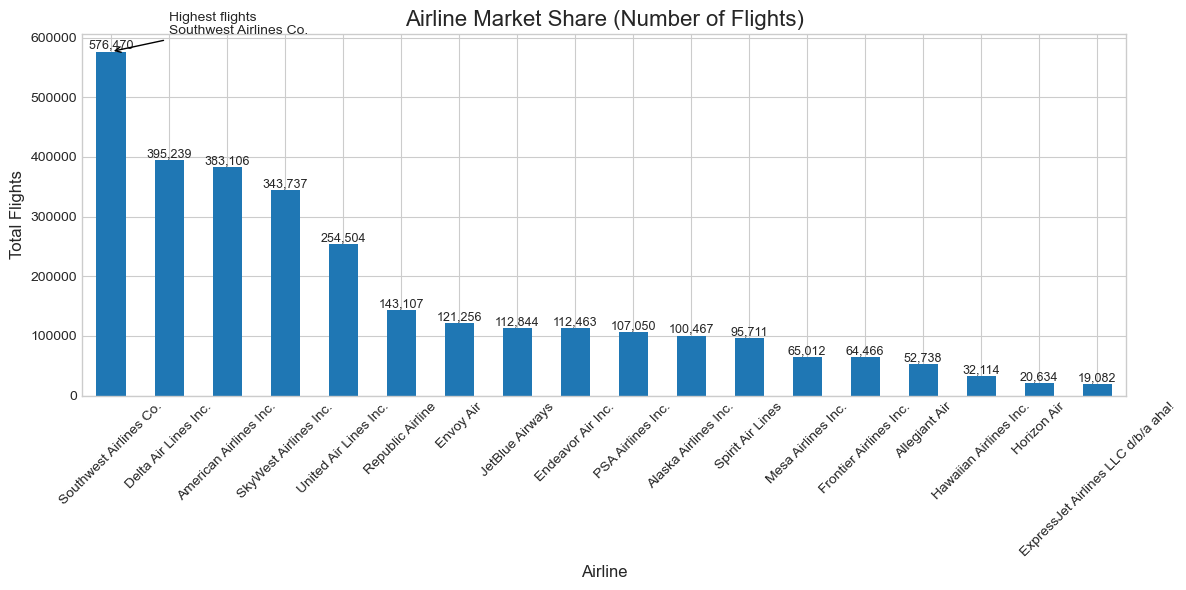

In [23]:
# ============================================
# FLIGHTS BY AIRLINE
# ============================================

airline_counts = df["AIRLINE"].value_counts().sort_values(ascending=False)

plt.figure()

ax = airline_counts.plot(kind="bar")

plt.title("Airline Market Share (Number of Flights)")
plt.xlabel("Airline")
plt.ylabel("Total Flights")

plt.xticks(rotation=45)

# add value labels
for i, v in enumerate(airline_counts):
    ax.text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)

# highlight largest airline
largest_airline = airline_counts.idxmax()
largest_value = airline_counts.max()

ax.annotate(
    f"Highest flights\n{largest_airline}",
    xy=(0, largest_value),
    xytext=(1, largest_value*1.05),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

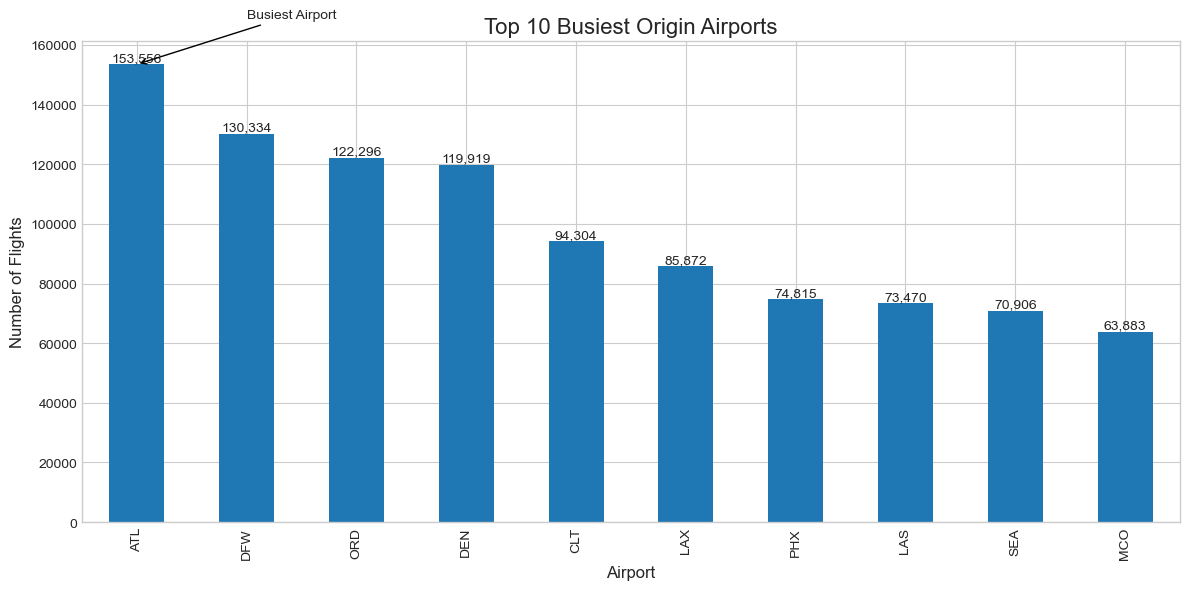

In [24]:
# ============================================
# BUSIEST ORIGIN AIRPORTS
# ============================================

top_airports = df["ORIGIN"].value_counts().head(10)

plt.figure()

ax = top_airports.plot(kind="bar")

plt.title("Top 10 Busiest Origin Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")

for i, v in enumerate(top_airports):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")

# highlight busiest airport
ax.annotate(
    "Busiest Airport",
    xy=(0, top_airports.iloc[0]),
    xytext=(1, top_airports.iloc[0]*1.1),
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

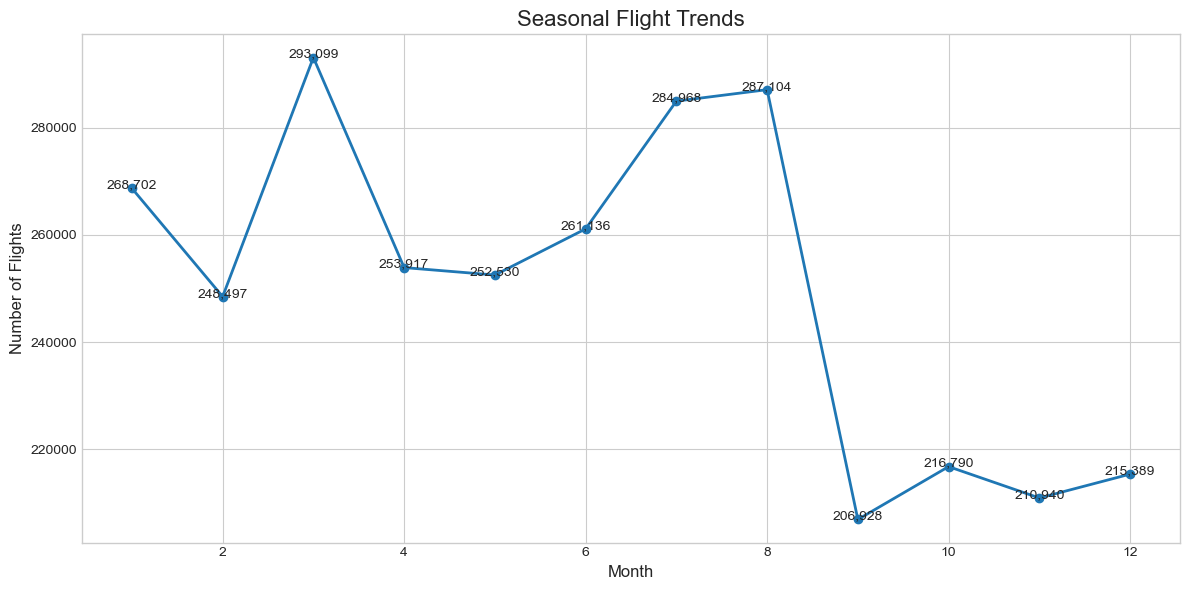

In [26]:
# ============================================
# FLIGHTS BY MONTH
# ============================================

monthly_flights = df.groupby("MONTH").size()

plt.figure()

ax = monthly_flights.plot(marker="o", linewidth=2)

plt.title("Seasonal Flight Trends")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

for i, v in enumerate(monthly_flights):
    ax.text(i+1, v, f"{v:,}", ha="center")

plt.grid(True)

plt.tight_layout()
plt.show()

- Max no. of flights are on March
- Min Max no. of flights are on September

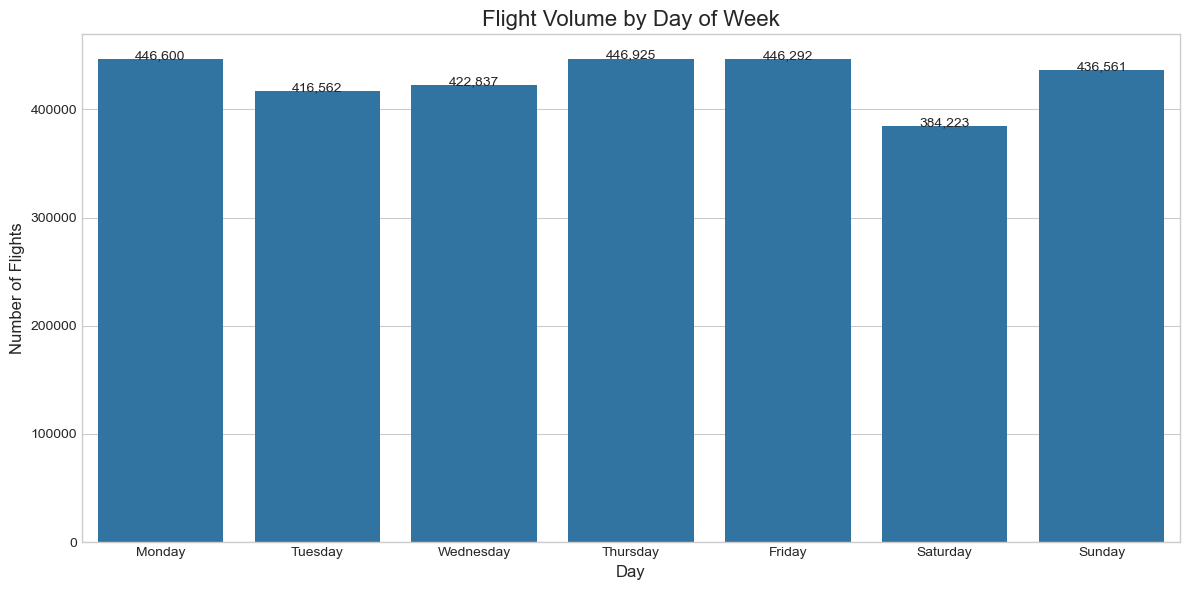

In [27]:
# ============================================
# FLIGHTS BY DAY OF WEEK
# ============================================

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

plt.figure()

ax = sns.countplot(data=df, x="DAY_OF_WEEK", order=order)

plt.title("Flight Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")

for p in ax.patches:
    height = int(p.get_height())
    ax.text(
        p.get_x()+p.get_width()/2.,
        height,
        f'{height:,}',
        ha="center"
    )

plt.tight_layout()
plt.show()

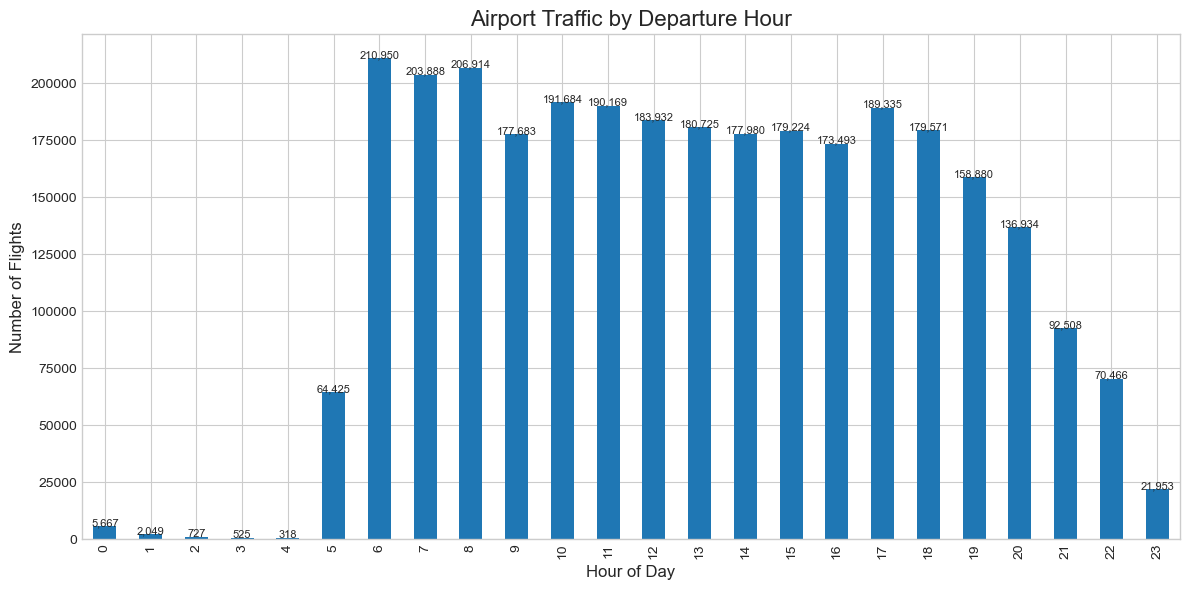

In [28]:
# ============================================
# FLIGHTS BY DEPARTURE HOUR
# ============================================

hour_counts = df["DEP_HOUR"].value_counts().sort_index()

plt.figure()

ax = hour_counts.plot(kind="bar")

plt.title("Airport Traffic by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")

for i, v in enumerate(hour_counts):
    ax.text(i, v, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

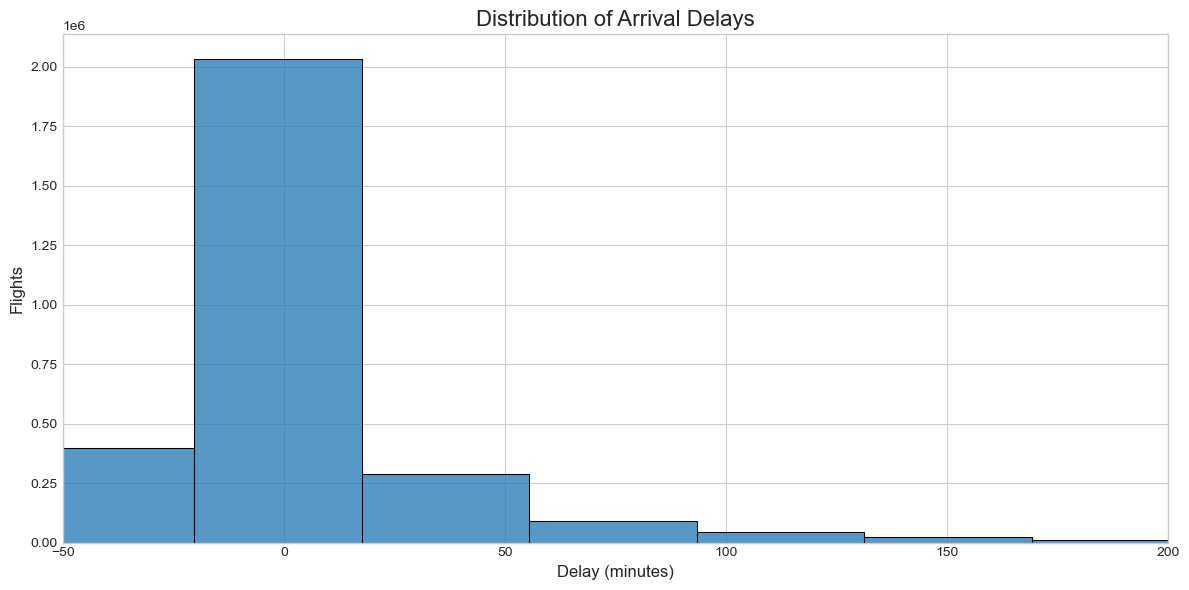

In [29]:
# ============================================
# ARRIVAL DELAY DISTRIBUTION
# ============================================

plt.figure()

sns.histplot(df["ARR_DELAY"].dropna(), bins=80)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Flights")

plt.xlim(-50,200)

plt.tight_layout()
plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_26824\107002847.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_delay = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values()


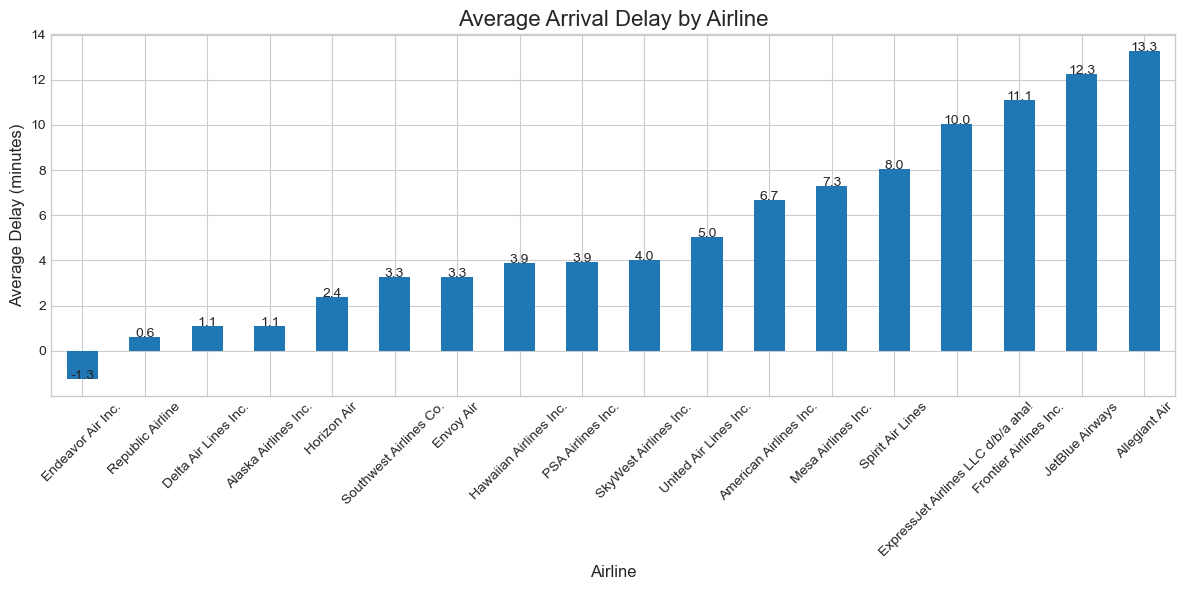

In [30]:
# ============================================
# AIRLINE DELAY PERFORMANCE
# ============================================

airline_delay = df.groupby("AIRLINE")["ARR_DELAY"].mean().sort_values()

plt.figure()

ax = airline_delay.plot(kind="bar")

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")

plt.xticks(rotation=45)

for i, v in enumerate(airline_delay):
    ax.text(i, v, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.show()

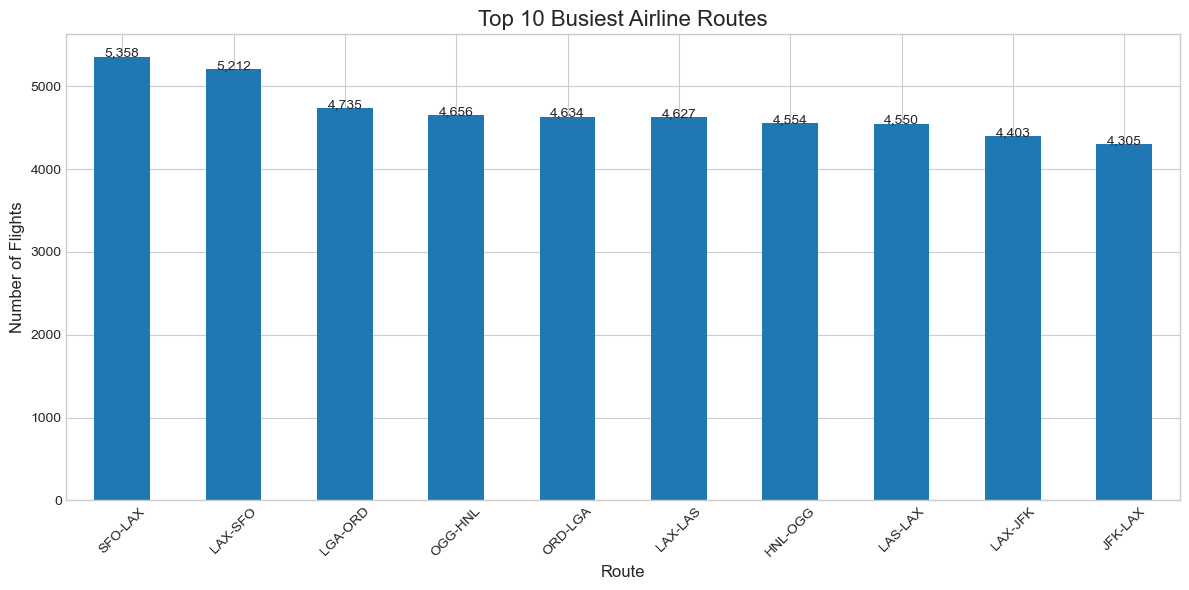

In [31]:
# ============================================
# TOP FLIGHT ROUTES
# ============================================

top_routes = df["ROUTE"].value_counts().head(10)

plt.figure()

ax = top_routes.plot(kind="bar")

plt.title("Top 10 Busiest Airline Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

for i, v in enumerate(top_routes):
    ax.text(i, v, f"{v:,}", ha="center")

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# TOTAL DELAY BY CAUSE
# ============================================

delay_cols = [
"DELAY_DUE_CARRIER",
"DELAY_DUE_WEATHER",
"DELAY_DUE_NAS",
"DELAY_DUE_SECURITY",
"DELAY_DUE_LATE_AIRCRAFT"
]

delay_totals = df[delay_cols].sum().sort_values(ascending=False)

print(delay_totals)

DELAY_DUE_LATE_AIRCRAFT    13598175.0
DELAY_DUE_CARRIER          13217960.0
DELAY_DUE_NAS               7028161.0
DELAY_DUE_WEATHER           2127583.0
DELAY_DUE_SECURITY            77907.0
dtype: float64


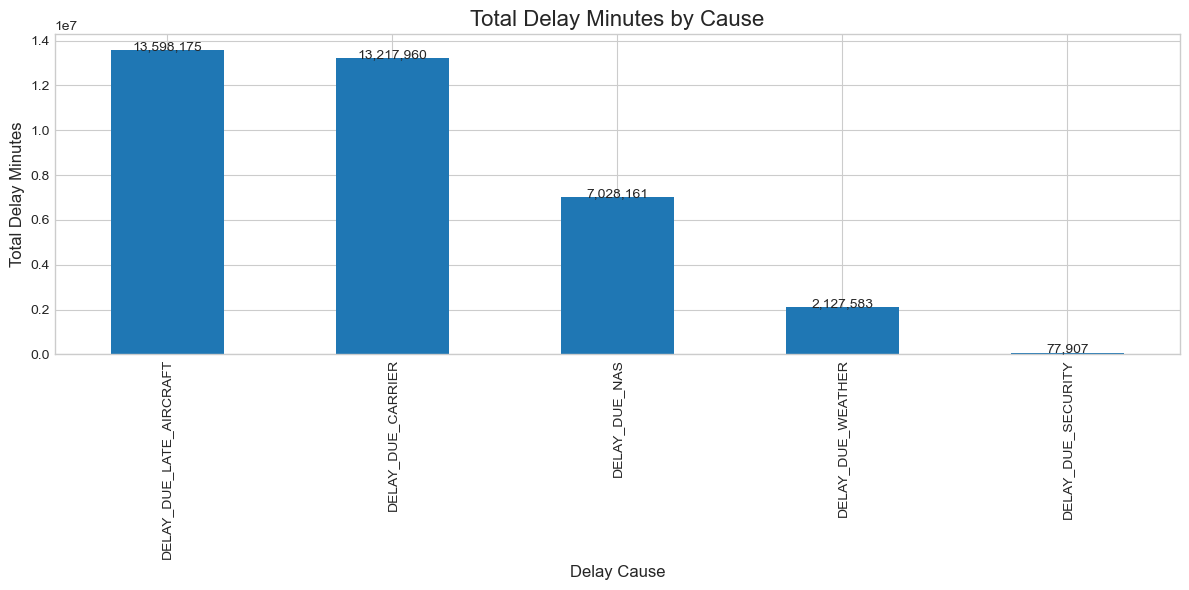

In [33]:
# ============================================
# DELAY CAUSE DISTRIBUTION
# ============================================

plt.figure(figsize=(12,6))

ax = delay_totals.plot(kind="bar")

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Total Delay Minutes")

for i, v in enumerate(delay_totals):
    ax.text(i, v, f"{int(v):,}", ha="center")

plt.tight_layout()
plt.show()

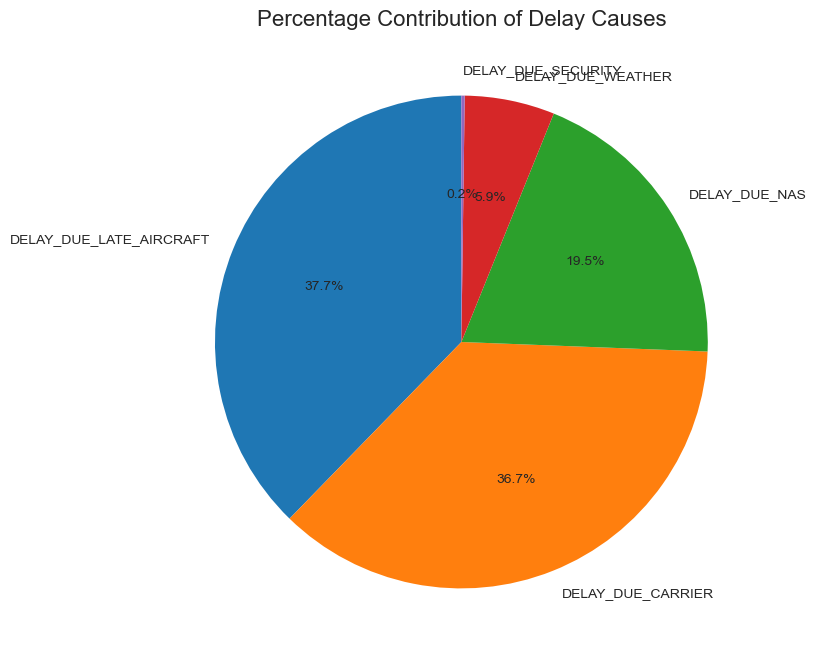

In [34]:
# ============================================
# DELAY CAUSE PERCENTAGE
# ============================================

delay_percent = delay_totals / delay_totals.sum() * 100

plt.figure(figsize=(8,8))

plt.pie(
delay_percent,
labels=delay_percent.index,
autopct="%1.1f%%",
startangle=90
)

plt.title("Percentage Contribution of Delay Causes")

plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_26824\1300068830.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_delay = df.groupby("AIRLINE")[delay_cols].mean()


<Figure size 1200x600 with 0 Axes>

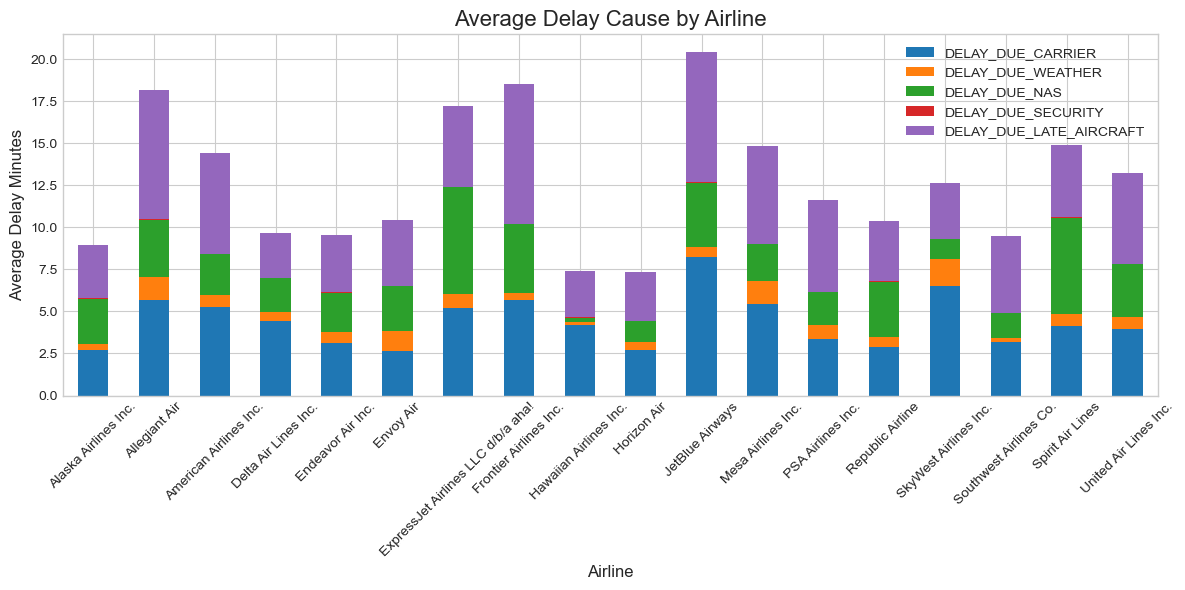

In [35]:
# ============================================
# DELAY CAUSE BY AIRLINE
# ============================================

airline_delay = df.groupby("AIRLINE")[delay_cols].mean()

plt.figure(figsize=(12,6))

airline_delay.plot(
kind="bar",
stacked=True,
figsize=(12,6)
)

plt.title("Average Delay Cause by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay Minutes")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\Robin\AppData\Local\Temp\ipykernel_26824\900288878.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_heatmap = df.groupby("AIRLINE")[delay_cols].mean()


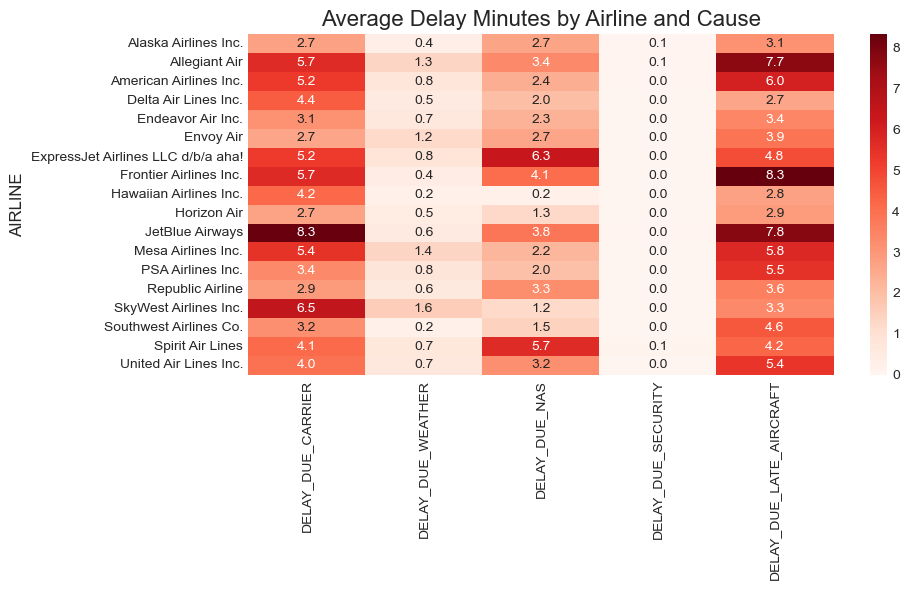

In [36]:
# ============================================
# DELAY HEATMAP
# ============================================

delay_heatmap = df.groupby("AIRLINE")[delay_cols].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
delay_heatmap,
annot=True,
fmt=".1f",
cmap="Reds"
)

plt.title("Average Delay Minutes by Airline and Cause")

plt.tight_layout()

plt.show()

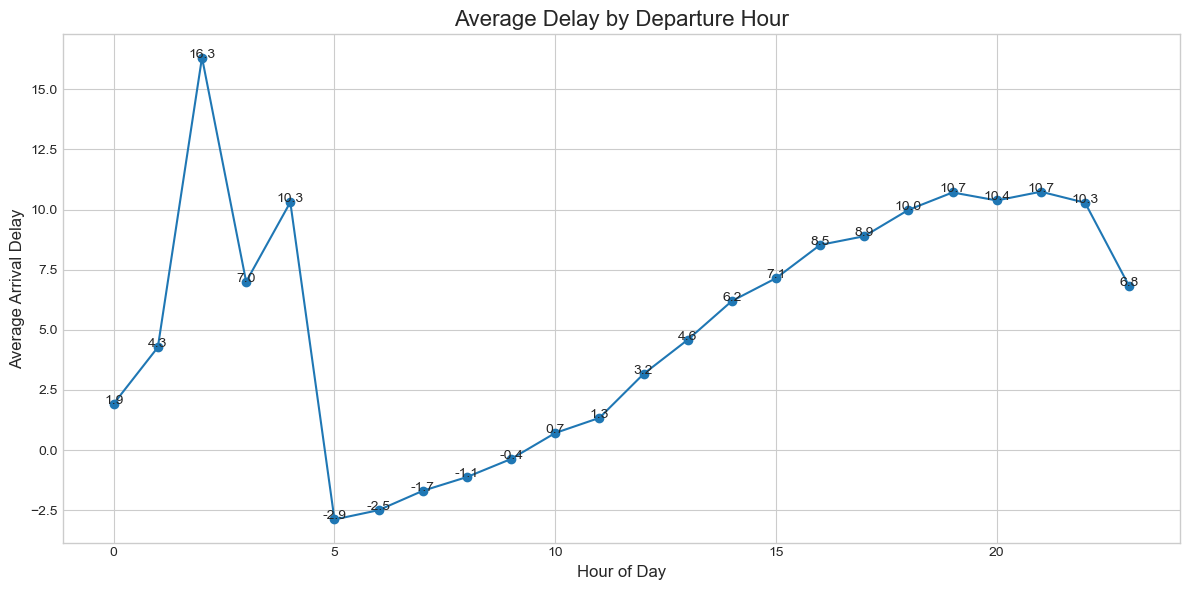

In [37]:
# ============================================
# DELAY BY DEPARTURE HOUR
# ============================================

hour_delay = df.groupby("DEP_HOUR")["ARR_DELAY"].mean()

plt.figure(figsize=(12,6))

ax = hour_delay.plot(marker="o")

plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Arrival Delay")

for i,v in enumerate(hour_delay):
    ax.text(i, v, f"{v:.1f}", ha="center")

plt.grid(True)

plt.tight_layout()
plt.show()

# Key Findings:
- Max Arrival delay is 16 min's on 3 AM
- Min Arrival delay is -2 min's on 5 AM

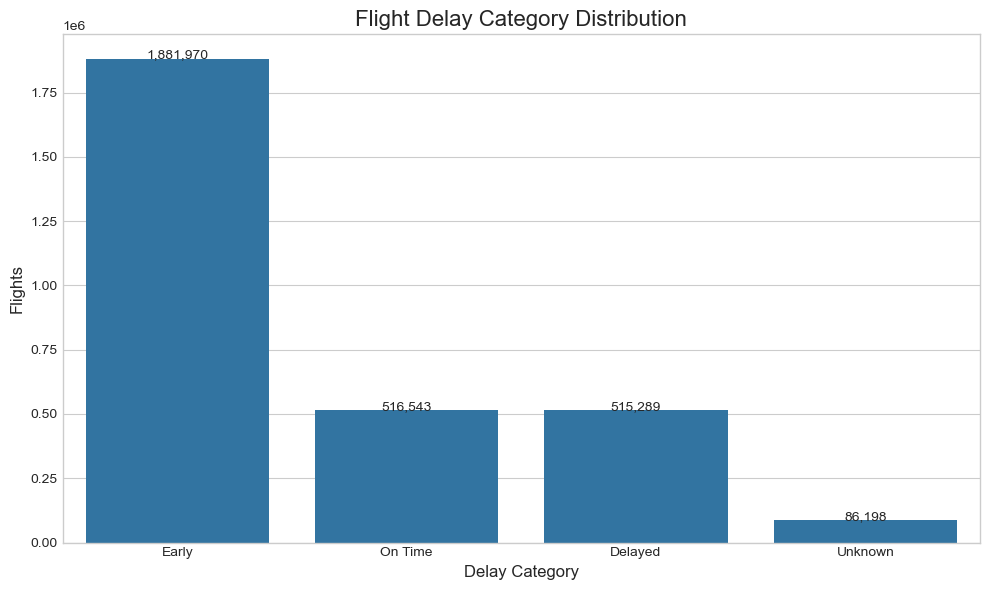

In [40]:
# ============================================
# DELAY CATEGORY DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

ax = sns.countplot(data=df, x="DELAY_CATEGORY")

plt.title("Flight Delay Category Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Flights")

for p in ax.patches:
    height = int(p.get_height())
    ax.text(
        p.get_x()+p.get_width()/2.,
        height,
        f'{height:,}',
        ha="center"
    )

plt.tight_layout()
plt.show()

# Key Findings:
-  Most of the flights arrive early